# Plots for the semi-solid paper
The plots presented in the 'Anamolous diffusion and effective shear modulus in a semisold membrane'

## Headers


In [18]:

import numpy as np
import matplotlib.pyplot as plt
import h5py, sys
import math
import json
from scipy.signal import savgol_filter
# plt.rcParams[font.sans-serif]       : CMU Serif 

plt.style.use("matplotlibrc")
plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = "CMU Serif"
plt.rcParams["font.sans-serif"]  = "CMU Serif"
#plt.rcParams["font.sans-serif"]  = "IBM Plex Serif"
csfont = {'fontname':'IBM Plex Serif'}
labelfont = {'fontname':'CMU Serif'}

prop_cycle = plt.rcParams['axes.prop_cycle']
clr = prop_cycle.by_key()['color']
dataFol = "data/"
# fig, ax = plt.subplots()
# ax.plot([2,2])
# ax.plot([1,2])
# ax.plot([3,2])



## Utils functions

In [19]:

def log_spaced(listIn, numint):
    exponent = math.log(listIn.shape[0], 1.2)
    log_integers = np.logspace(0, exponent, num=numint, base=1.2, dtype=int) - 1
    spacing = np.unique(log_integers)
    indices = spacing[spacing < listIn.shape[0]]
    listOut = listIn[indices]
    return indices, listOut

def obtainMu(ener_2d, shrs):
    niters = ener_2d.shape[1]
    mu, exponent = [], []
    shr2 = shrs*shrs
    for i in range(0,niters):
        ener_2dn = ener_2d[:,i] - ener_2d[0,i]
        m, c = np.polyfit(shr2, ener_2dn, 1)
        mu.append(m)
        exponent.append(c)
    mun = np.mean(np.asarray(mu))
    expn = np.mean(np.asarray(exponent))
    mun_std = np.std(mun)
    return mun, expn, mun_std

def fractionSolid(Nsolid, NT):
    NumTri = 2*NT - 4*np.sqrt(NT) - 2
    return float(6.0*Nsolid/NumTri)



## Functions to load the data 
- All data are inside the `data` folder

In [20]:
def readMsdDataset(grp,res):
    fname = dataFol+"/msd"+res+".h5"
    with h5py.File(fname, 'r') as f:
        sm = f[grp]
        tMsd = sm['msd'][:]
        alp = sm['Alpha'][()]
        Diff = sm['D'][()]
        Nsolid = sm['Nsolid'][()]
        stdalp = sm['stdAlpha'][()]
        stdDiff = sm['stdD'][()]
    return tMsd, alp, Diff, Nsolid, stdalp, stdDiff

def firstPassageData(grp, sgrp):
    fname = dataFol+"/Fpstats64K.h5"
    with h5py.File(fname, 'r') as f:
        sm1 = f[grp]
        sm = sm1[sgrp]
        tqpdf = sm['fpqpdf'][:]
        rcut = sm['RCut'][()]
        Nsolid = sm1['Nsolid'][()]
    return tqpdf, rcut, Nsolid

def ShearData(fname):
    with open(dataFol+fname, 'r') as file:
        Alldata = json.load(file)
    return Alldata

def readHdf5(fn, grpname):
    hf = h5py.File(fn,'r')
    data = hf[grpname][()]
    hf.close()
    return data

## Plotting functions


## Trajectories plot 


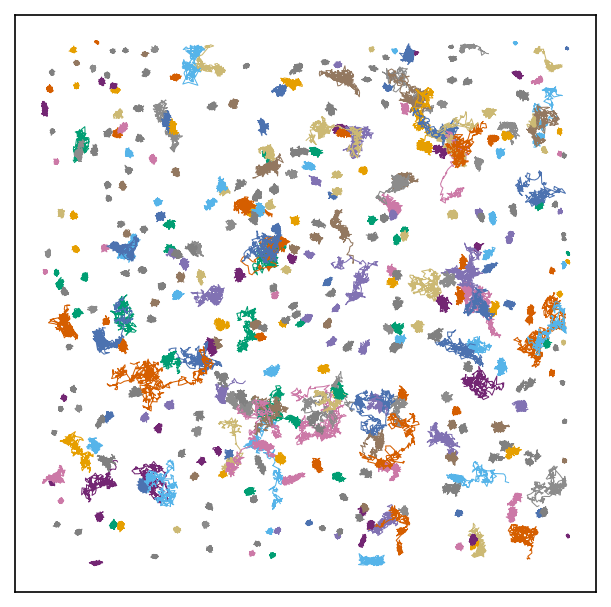

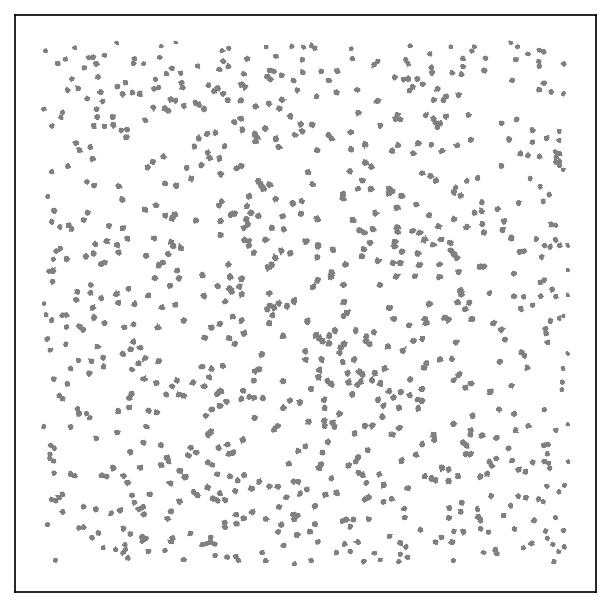

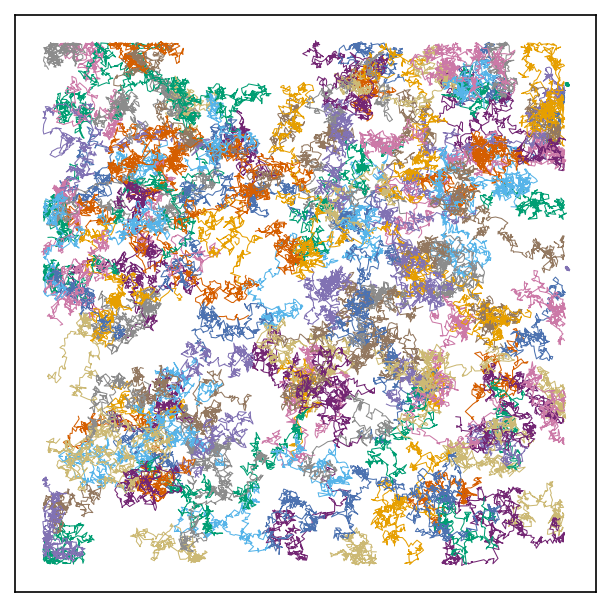

In [21]:
from cycler import cycler

filen = [dataFol+"FluidTraj.h5",  dataFol+"Sm10Traj.h5", dataFol+"SolidTraj.h5"] 

fig, ax = plt.subplots(figsize=(5,5))  
for ir in range(0,300):
    tr = readHdf5(filen[1], "fluid/traj"+str(ir))
    ax.plot(tr[:300,0], tr[:300,1], "-", linewidth=0.5)
for ir in range(0,100):
    tr = readHdf5(filen[1], "solid/traj"+str(ir))
    ax.plot(tr[:300,0], tr[:300,1], "-", linewidth=0.5, color="gray")
ax.set(xticks=[], yticks=[])
# fig.savefig("/home/vikash/Documents/my_papers/semi_solid_membrane/data/membrane-snaps/sm10_traj.png")
plt.show()

fig, ax = plt.subplots(figsize=(5,5))  
for ir in range(101,1024):
    tr = readHdf5(filen[2], "solid/traj"+str(ir))
    ax.plot(tr[:300,0], tr[:300,1], "-", linewidth=0.5, color="gray")
ax.set(xticks=[], yticks=[])
# fig.savefig("/home/vikash/Documents/my_papers/semi_solid_membrane/data/membrane-snaps/solid_traj.png")
plt.show()
fig, ax = plt.subplots(figsize=(5,5))  
for ir in range(0,200):
    tr = readHdf5(filen[0], "fluid/traj"+str(ir))
    ax.plot(tr[:300,0], tr[:300,1], "-", linewidth=0.5)
ax.set(xticks=[], yticks=[])
# fig.savefig("/home/vikash/Documents/my_papers/semi_solid_membrane/data/membrane-snaps/fluid_traj.png")

plt.show()



## Mean Square displacement

In [22]:
smldg = [
       "fluid", "sm1", "sm2", "sm3", "sm4",
       "sm5", "sm6", "sm7", "sm8", "sm9",
       "sm10", "sm11"]

smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]

se = np.asarray([0,5,8,10,11], dtype=int)
N = np.asarray([16384, 65536], dtype=int)
dl = 2*np.pi/np.sqrt(N[1])
A_s = dl*dl

def plotMsd(fig, ax1):
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset('fluid', "64KAll")
    xx = 1e3*tMsd[0][2:]; yy = tMsd[1][2:] 
    m, c = np.polyfit(np.log10(xx[xx>2e1]), np.log10(yy[xx>2e1]), 1)
    Dl = 10**c

    for i, idx_p in enumerate(se):
        tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(smldg[idx_p], "64KAll")
        xx, yy = log_spaced(tMsd[1][1:],25)
        xx = 1e3*xx*Dl/A_s; yy = yy/A_s 
        phi = fractionSolid(Nsolid, N[1]) ## Pass the point corresponding to N=65536
        l1 = ax1.plot(xx[1:], yy[1:], "-"+smbl[idx_p], color=clr[i], markerfacecolor='none',
                      markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(phi))

    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset("solid", "64K_solid")
    xx, yy = log_spaced(tMsd[1][1:],25)
    xx = 1e3*xx*Dl/A_s; yy = yy/A_s 
    l1 = ax1.plot(xx[1:], yy[1:], "-"+smbl[idx_p+1], color=clr[i+1], markerfacecolor='none',
                  markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(1.0))
    ax1.set(ylabel=r"$R^2$")
    xx = np.linspace(10,2000,1000)
    ax1.plot(xx, 1.2*xx, '--k', linewidth=2)
    ax1.arrow(0.5, 0.8, 0.1, -0.5, transform=ax1.transAxes, length_includes_head=True,
               head_width=0.02, color="gray", visible=True, linewidth=2)
    x = 2;




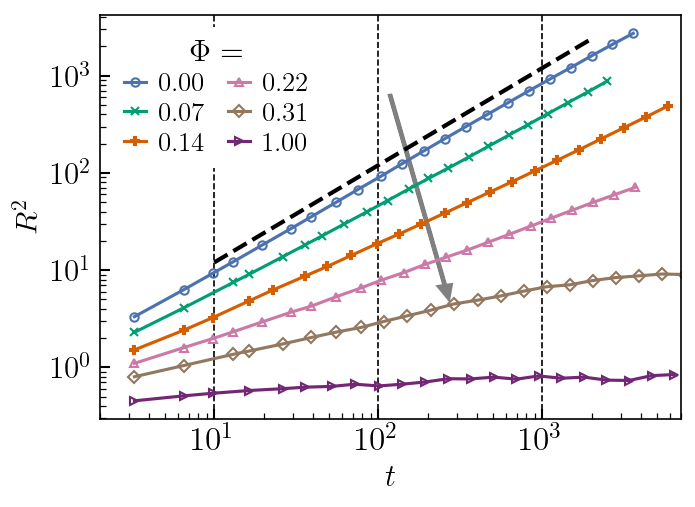

In [23]:
fig, ax = plt.subplots(1,1,  sharex=True,
           gridspec_kw={'hspace':0.2} ) 
#ax = ax.reshape(-1)
plotMsd(fig, ax)
#ax[0].grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
ax.grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
# ax[1].grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
ax.set(xscale='log', yscale='log')
# ax[1].set(yscale="linear", xscale="log", xlim=[2,5e3])
# ax[1].set_xlabel(r"$t$", **labelfont)
# ax[1].set_ylabel(r"$\beta(t)$", **labelfont)
#ax[1].set_ylabel(r"$F_{\rm s}(t)$", **labelfont)
plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
ax.legend(title=r'$\Phi=$ ', fontsize=13, ncols=2, frameon=True,fancybox=False, edgecolor="white", framealpha=1)
#plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
ax.set(xlabel=r"$t$", xlim=[2,7e3])
#
plt.show()

## F<sub>s</sub>(k,t) versus time plot


In [26]:

def readFS(fn, coln):
    fname = dataFol+"FS_all64k/"+fn+"N.txt"
    tt, FS = np.loadtxt(fname, unpack=True, usecols=(0,coln))
    return tt[::2], FS[::2]

smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]
def plotFS(fig, ax2):
    se = np.asarray([0,5,8,10,11], dtype=int)
    N = np.asarray([16384, 65536], dtype=int)
    dl = 2*np.pi/np.sqrt(N[1])
    A_s = dl*dl
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset('fluid', "64KAll")
    xx = 1e3*tMsd[0][2:]; yy = tMsd[1][2:] 
    m, c = np.polyfit(np.log10(xx[xx>2e1]), np.log10(yy[xx>2e1]), 1)
    Dl = 10**c

    for i, idx_p in enumerate(se):
        tt, Fs = readFS(smldg[idx_p], 2)
        tt = 1e3*(tt)*Dl/A_s; Fs = Fs/Fs[0] 
        tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(smldg[idx_p], "64KAll")
        phi = fractionSolid(Nsolid, N[1]) ## Pass the point corresponding to N=65536
        l1 = ax2.plot(tt, Fs, "-"+smbl[idx_p], color=clr[i], markerfacecolor='none',
                      markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(phi))


    tt, Fs = readFS('solid', 2)
    tt = 1e3*(tt)*Dl/A_s; Fs = Fs/Fs[0] 
    l1 = ax2.plot(tt, Fs, "-"+smbl[idx_p+1], color=clr[i+1], markerfacecolor='none',
                  markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(1.0))

    ax2.arrow(0.5, 0.3, 0.2, 0.6, transform=ax2.transAxes, length_includes_head=True,
               head_width=0.02, color="gray", visible = True, linewidth=2)





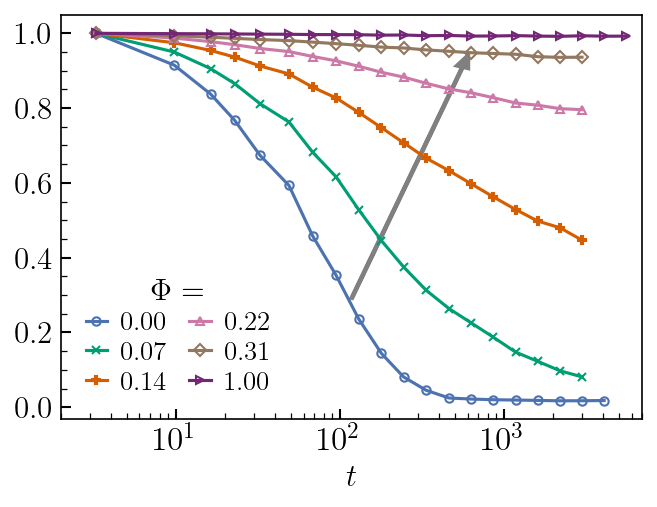

In [32]:
fig, ax = plt.subplots(1,1,  sharex=True,
           gridspec_kw={'hspace':0.2} ) 
#ax = ax.reshape(-1)
# plotMsd(fig, ax)
# plotAlphaTime(fig, ax[1])
plotFS(fig, ax)

space_between_plots = plt.rcParams["figure.subplot.hspace"]  # <==========
# ax.grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
# ax[1].grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
ax.set(xscale='log', yscale='linear')
plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
ax.legend(title=r'$\Phi=$ ', fontsize=13, ncols=2, frameon=True,fancybox=False, edgecolor="white", framealpha=1)
#plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
ax.set(xlabel=r"$t$", xlim=[2,7e3])
#ax.text(-0.1, 1.0, "(A)", transform=ax[0].transAxes,**csfont, fontweight=450)
# ax[1].text(-0.1, 1.0, "(B)", transform=ax[1].transAxes,**csfont, fontweight=450)
#print(space_between_plots) 
plt.show()



## Deff scaling

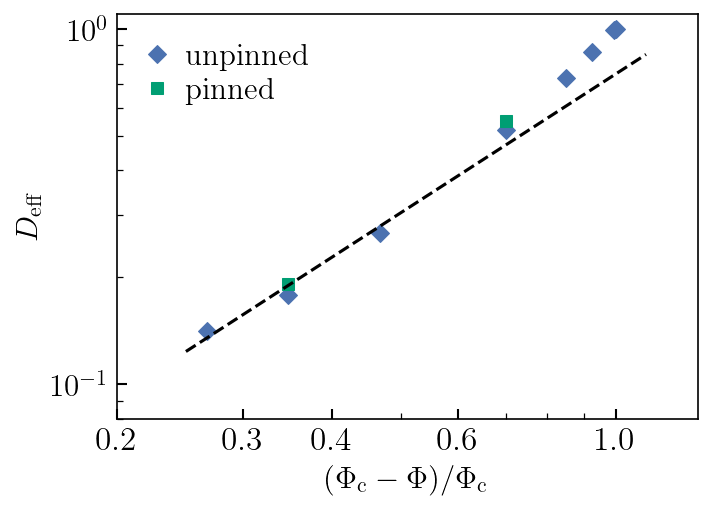

In [33]:
this = np.loadtxt(dataFol+"/prev_results/deff_phi.txt")
anch = np.loadtxt(dataFol+"/prev_results/deff_phi_a.txt")
fig, ax = plt.subplots()
phic = 0.2206
ax.plot((phic-this[:-3,0])/phic, this[:-3,1]/this[0,1], "D", markersize=6, label=r"unpinned")
ax.plot((phic-anch[:-2,0])/phic, anch[:-2,1]/this[0,1], "s", markersize=6, label=r"pinned")
ax.set(xlabel=r"$(\Phi_{\rm c} - \Phi)/\Phi_{\rm c}$", ylabel=r"$D_{\rm eff}$", yscale="log", xscale="log")
ax.set(xlim=[0.2, 1.3], xticks=[0.2, 0.3, 0.4, 0.6, 1.0], xticklabels=["0.2","0.3","0.4", "0.6", "1.0"])
ax.set(ylim=[0.08,1.1])
ax.legend()
xx = np.linspace(0.25,1.1,10)
ax.plot(xx, 0.75*xx**1.3, '--k')
# plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
# ax.text(-0.1, 1.0, "(D)", transform=ax.transAxes,**csfont, fontweight=450)
# plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
#fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/DeffPhiscaling.pdf")
plt.show()



## $\Delta E$  vs time

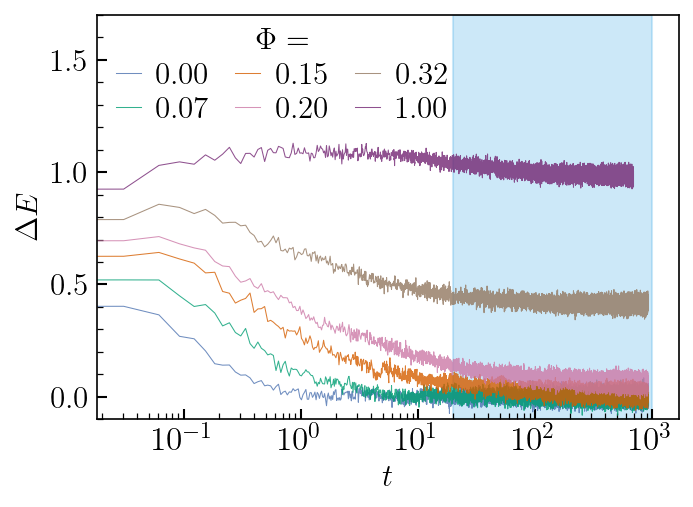

In [34]:
Shrdct = ["shr0", "shr1", "shr2", "shr3", "shr4", "shr5", "shr6", "shr7", "shr8", "shr9"]
N = np.asarray([16384, 65536], dtype=int)
ts = 326.0
def Etimeinf(fname, sh):
    data0 = readHdf5(fname, "E/"+Shrdct[0])
    Einf = np.mean(data0[3000:,1] + data0[3000:,2])
    data = readHdf5(fname, "E/"+sh)
    tt = data[:,0]/ts
    Et = data[:,1] + data[:,2]
    shear = readHdf5(fname, "shear/"+sh)
    return tt, Et-Einf, shear
## solid
se = np.asarray([0,5,8,10,11], dtype=int)
filn = ["/EnerTimeFluid.h5", "EnerTimesmld5.h5","EnerTimesmld8.h5","EnerTimesmld10.h5", "EnerTimesmld11.h5","EnerTimeSolid.h5"]
phi = [0.0, 0.07, 0.15, 0.20, 0.32, 1.0]
# filn = dataFol+"/EnerTimeSolid.h5"
fig, ax  = plt.subplots( )
for i,ff in enumerate(filn):
   tt, Et, shear = Etimeinf(dataFol+ff, "shr7")
   l1, = ax.plot(tt, Et, "-", alpha=0.8, linewidth=0.5, label=r"$%0.2f$"%(phi[i]))
   Et = savgol_filter(Et, 50, 3) # window size 51, polynomial order 3
   #ax.plot(tt, Et, '-', color=l1.get_color(), label=r"$%0.2f$"%(shear)) 

ax.legend(title=r"$\Phi=$", ncols=3, loc=(0.01,0.7))
ax.set(xscale="log", ylim=[-0.1, 1.7], xlabel=r"$t$", ylabel=r"$\Delta E$")
#ax.set(yticks=[0,1.0,2.0,3.0], yticklabels=["0.0", "1.0", "2.0", "3.0"])
#ax.set(yticks=[0,0.4,0.8,1.2], yticklabels=["0.0", "0.4", "0.8", "1.2"])
ax.axvspan(20, 1e3, alpha=0.3, color=clr[6])

# plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
# ax.text(-0.1, 1.0, "(A)", transform=ax.transAxes,**csfont, fontweight=450)
# plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
# fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/EtimeSmldphi.pdf")
# fig.savefig("/home/vikash/Documents/my_papers/semi_solid_membrane/fig/EtimeSolid.pdf")
plt.show()




## $\Delta E_\infty$  vs $\Phi$

/tmp/ipykernel_27010/3559715421.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('magma', 12)


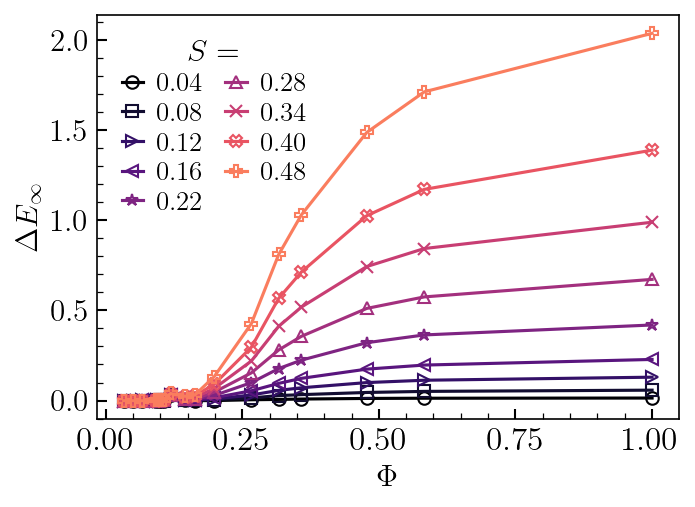

In [14]:
import matplotlib
from matplotlib import cm

#normalize item number values to colormap
norm = matplotlib.colors.Normalize(vmin=0, vmax=1000)

#colormap possible values = viridis, jet, spectral

Anchkey1 = ["fluid", "sm1", "sm2", "sm3", "sm4", "sm5", "sm6", "sm7", "sm8", "sm9", "sm10", "sm11"]
Freekey1 = [ "solid", "sm3", "sm4", "sm5", "sm6", "sm8", "sm9", "sm10", "sm11"]
Freekey2 = [ "sm6p2", "sm6p4", "sm6p6", "sm6p8", "sm7", "sm10p5", "sm12", "sm13", "sm14"]
Anchfile1 = "../data/ShearAnchoredData.json" 
Freefile1 = "../data/ShearFreeData.json" 
Freefile2 = "../data/ShearFreeData_dardel1.json" 
Freefile3 = "../data/ShearSolidData.json" 
Shrdct = ["shr0", "shr1", "shr2", "shr3", "shr4", "shr5", "shr6", "shr7", "shr8", "shr9"]

N = np.asarray([16384, 65536], dtype=int)

rgba_color = cm.cividis(norm(len(Freekey1) + len(Freekey2) + 1),bytes=True) 

smbl = ['o', 's','>', '<','*','^','x','X', 'P', 'D']
def getEinf(infile, topkey, shkey):
    data1 = ShearData(infile[0])
    data2 = ShearData(infile[1])
    data3 = ShearData(infile[2])
    data = {**data1, **data2, **data3}
    topkey.append("solid")
    sh0 = "shr0"
    mu = []; mustd = []; phi = [];
    Em = []; Estd = []; ns = []
    for tk in topkey:
        stretchE = data[tk][sh0]["se"]
        bendE = data[tk][sh0]["be"]
        totE0 = np.asarray(stretchE) + np.asarray(bendE)
        Nsolid = data[tk][sh0]["Nsolid"]
        ns.append(Nsolid)
        phi.append(fractionSolid(Nsolid, N[0]))     ## Pass the point corresponding to N=65536
        stretchE = data[tk][shkey]["se"]
        bendE = data[tk][shkey]["be"]
        totEN = np.asarray(stretchE) + np.asarray(bendE)
        Em.append(np.mean(totEN - totE0))
        Estd.append(np.std(totEN - totE0))
        shear = data[tk][shkey]["shear"]
        key = np.argsort(phi)
    return np.asarray(phi)[key], np.asarray(Em)[key], np.asarray(Estd)[key], np.asarray(ns)[key], shear

fig, ax = plt.subplots() 
cmap = plt.cm.get_cmap('magma', 12)

for i, shd in enumerate(Shrdct[1:]):
   phi, Em, Estd, ns, shear = getEinf([Freefile1, Freefile2, Freefile3], Freekey1+Freekey2, shd )
   phi = np.hstack([phi, 1.0])#[-1] = 1; phi[0] = 0
   Em = np.hstack([Em, Em[0]])#[-1] = 1; phi[0] = 0
#   Em[-1] = Em[0]; Em[0] = 0
   ax.plot(phi[2:], Em[2:], "-", marker=smbl[i], markersize=6, color=cmap(i),
           markeredgewidth=1, markerfacecolor="none", label=r"$%0.2f$"%(shear))
#   print(shear)

ax.legend(title=r'$S=$ ', fontsize=13, ncols=2)
ax.set(xlabel=r"$\Phi$", ylabel=r"$\Delta E_\infty$")

# plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
# ax.text(-0.1, 1.0, "(B)", transform=ax.transAxes,**csfont, fontweight=450)
# plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
# fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/EphiS.pdf")
plt.show()
# Need to write a function for the energy part.


## $\Delta E_\infty$ vs S

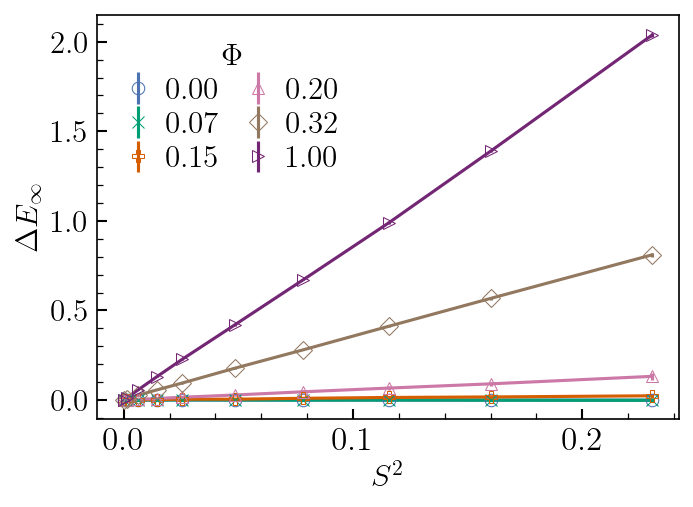

In [16]:
## this plot is for free membrane
Anchkey = ["fluid", "sm1", "sm2", "sm3", "sm4", "sm5", "sm6", "sm7", "sm8", "sm9", "sm10", "sm11"]
Shrdct = ["shr0", "shr1", "shr2", "shr3", "shr4", "shr5", "shr6", "shr7", "shr8", "shr9"]
Freekey = [ "sm3", "sm4", "sm5", "sm6", "sm8", "sm9", "sm10", "sm11"]
N = np.asarray([16384, 65536], dtype=int)


def EnerShear(data, key, smid):
    ener_2d = np.asarray([])
    shrs = []
    Nsolid = data[smid][Shrdct[0]]["Nsolid"]
    phi = fractionSolid(Nsolid, N[0]) ## Pass the point corresponding to N=65536
    shape_idx = 0; 
    for sh in Shrdct:
        stretchE = data[smid][sh]["se"]
        bendE = data[smid][sh]["be"]
        totE = np.asarray(stretchE) + np.asarray(bendE)
        shape_idx = shape_idx + 1 
        ener_2d = np.hstack([ener_2d, totE])
        shrs.append(data[smid][sh]["shear"])
    ener_2d = ener_2d.reshape(shape_idx, len(totE))
    ener_new = np.mean(ener_2d-ener_2d[0,:], axis=1)
    ener_std = np.std(ener_2d-ener_2d[0,:], axis=1)
    shrs = np.asarray(shrs)
    return ener_new, ener_std, shrs, phi



# Need to write a function for the energy part.
fig, ax = plt.subplots()
dataF = ShearData("ShearFreeData.json")
dataA = ShearData("ShearAnchoredData.json")
dataS = ShearData("ShearSolidData.json")

se = np.asarray([0,5,8,10,11], dtype=int)
smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]

idx = 0
E, E_std, shrs, phi = EnerShear(dataA, Anchkey, 'fluid')
l1, = ax.plot(shrs[:]**2, E[:], "-")
ax.errorbar(shrs[:]**2, E[:], yerr=E_std[:], 
           fmt=smbl[idx], color = l1.get_color(), label=r"$%0.2f$"%(phi),
            markerfacecolor='none', markersize=6)

for idx in se[1:-1]:
    E, E_std, shrs, phi = EnerShear(dataF, Anchkey, Anchkey[idx])
    l1, = ax.plot(shrs[:]**2, E[:], "-")
    ax.errorbar(shrs[:]**2, E[:], yerr=E_std[:], 
           fmt=smbl[idx], color = l1.get_color(), label=r"$%0.2f$"%(phi),
            markerfacecolor='none', markersize=6)

E, E_std, shrs, phi = EnerShear(dataF, Anchkey, Anchkey[se[-1]])
l1, = ax.plot(shrs[:]**2, E[:], "-")
ax.errorbar(shrs[:]**2, E[:], yerr=E_std[:], 
           fmt=smbl[idx+1], color = l1.get_color(), label=r"$%0.2f$"%(phi),
            markerfacecolor='none', markersize=6)


E, E_std, shrs, phi = EnerShear(dataS, Anchkey, 'solid')
l1, = ax.plot(shrs[:]**2, E[:], "-")
ax.errorbar(shrs[:]**2, E[:], yerr=E_std[:], 
           fmt=smbl[idx+2], color = l1.get_color(), label=r"$%0.2f$"%(1.0),
            markerfacecolor='none', markersize=6)
ax.set(xlabel=r"$S^2$", ylabel=r"$\Delta E_\infty$")
ax.legend(title=r"$\Phi$", ncols=2)

#plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
#ax.text(-0.1, 1.0, "(C)", transform=ax.transAxes,**csfont, fontweight=450)
#plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
##fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembraneNew/fig/Ener_strain_16k.pdf")
plt.show()



## $D_{eff}$ vs $\mu$ together

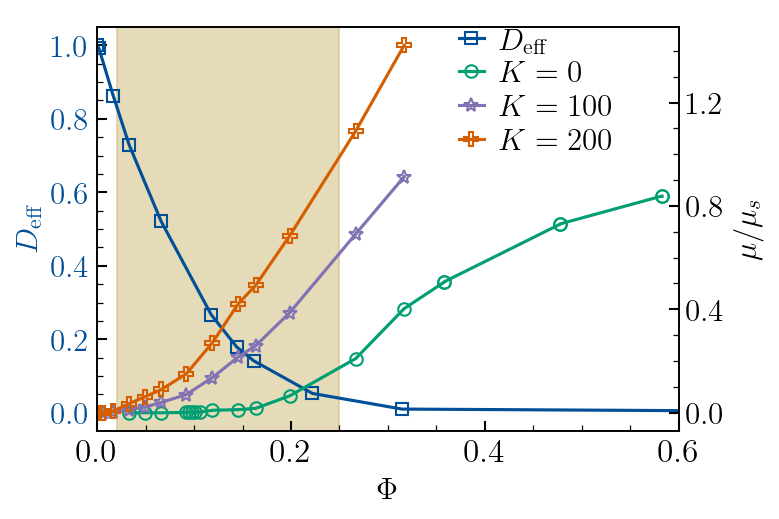

In [17]:
N = np.asarray([16384, 65536], dtype=int)
# Read the mu versus 
deff = np.loadtxt(dataFol+"/prev_results/deff_phi.txt")
df1 = np.loadtxt(dataFol+"muPhiFree1.dat")  
df2 = np.loadtxt(dataFol+"muPhiFree2.dat")  
df = np.vstack([df1, df2])
df = df[df[:, 0].argsort()]
da1 = np.loadtxt(dataFol+"muPhiAnch1.dat")  
da2 = np.loadtxt(dataFol+"muPhiAnchP2.dat")  
mus = 8.8

fig, ax = plt.subplots()
ax.plot(deff[:,0], deff[:,1]/deff[0,1], "-s", color="#004F98", markersize=6, markerfacecolor="none",
        markeredgewidth=1,  label=r"$D_{\rm eff}$")

ax2 = ax.twinx() 


ax2.plot(df[:,0], df[:,1]/mus, '-o', markersize=6, markeredgewidth=1,
          markerfacecolor="none", color=clr[1], label=r"$K=0$")
ax2.plot(da2[:,0], da2[:,1]/mus, '-*', markersize=7, markeredgewidth=1,
         markerfacecolor="none", color=clr[8], label=r"$K=100$")
ax2.plot(da1[:,0], da1[:,1]/mus, '-P', markersize=7, markeredgewidth=1,
         markerfacecolor="none", color=clr[2], label=r"$K=200$")
ax.legend(loc=(0.6,0.90))
ax2.legend(loc=(0.6,0.65))
# ax.axvline(da[3,0], ls='-', color='k')
# ax.axvline(0.25, ls='-', color='k')

ax.axvspan(0.02, 0.25, alpha=0.5, color=clr[7])
# ax.axvline(0.18, ls='--', color='k')
ax.set(yticks=[0,0.2,0.4,0.6,0.8,1.0], yticklabels=["0.0","0.2","0.4","0.6","0.8","1.0"])
ax.set(xlim=[0,0.6], xlabel=r"$\Phi$")
ax.set_ylabel(r"$D_{\rm eff}$", color="#004F98")
ax2.set(xlim=[0,0.6],  ylabel=r"$\mu/\mu_s$")
ax2.set(yticks=[0,0.4,0.8,1.2], yticklabels=["0.0", "0.4",  "0.8", "1.2"])
ax.tick_params(axis ='y', labelcolor = "#004F98") 
plt.show()


## Spectra plot


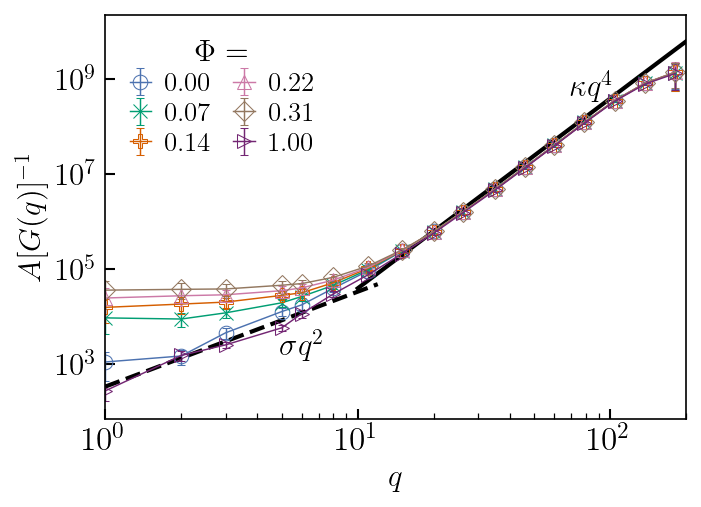

In [18]:
files = ["fluid.dat", "smld5.dat", "smld8.dat", "smld10.dat", "smld11.dat", "solid.dat"]
phis = [0.0, 0.07, 0.14, 0.22, 0.31, 1.0] 
fig, ax = plt.subplots()
#se = np.asarray([0,5,8,9,10,11], dtype=int)
kappa = 4.0
se = np.asarray([0,5,8,10,11,12], dtype=int)
smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]
numpt = 20
for j,i in enumerate(se):
    f = dataFol+"/spectra/"+files[j]
    k, hk, hk_err = np.loadtxt(f, unpack=True, usecols=(0,1,2))
    x, k = log_spaced(k, numpt); x, hk = log_spaced(hk, numpt); x, hk_err = log_spaced(hk_err, numpt)
    ax.errorbar(k, 1/hk, yerr=(hk_err/(hk**2)), marker=smbl[i], markerfacecolor='none', alpha=1.0,
                 markersize=7, linewidth=0.7, capsize=2, label=r"$%0.2f$"%(phis[j]))

#ax.text(0.1,0.8, r'$\Phi=$', transform=ax.transAxes)
xx = np.linspace(1.0,12, 12)
ax.plot(xx, 340.0*xx**2, '--k', lw=2)
xx = np.linspace(10,220, 100)
t, xx = log_spaced(xx, 20)
ax.plot(xx, 4*xx**4, '-k', lw=2)
ax.set(xscale='log', yscale='log', xlim=[1,200])
ax.text(0.8,0.8, r'$ \kappa q^4$', transform=ax.transAxes)
ax.text(0.3,0.16, r'$ \sigma q^2$', transform=ax.transAxes)

ax.legend(title=r'$\Phi=$ ', fontsize=13, ncols=2)
ax.set(xlabel=r"$q$", ylabel=r"$A[G(q)]^{-1}$")
# fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/specPhi.pdf")
plt.show()




# Supplementary Plots

## Msd exponent at various N

(12,)


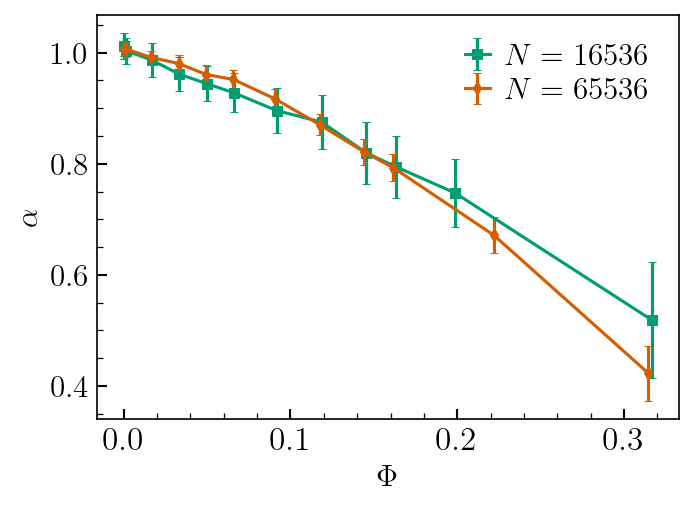

In [19]:
Alp_64k, Alp_16k, phi_64k, phi_16k = [], [], [], []
Alp_64k_er, Alp_16k_er = [], []
for sm in smldg:
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(sm, "64K")
    Alp_64k.append(alp); Alp_64k_er.append(stdalp) 
    phi_64k.append(fractionSolid(Nsolid, N[1]))
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(sm, "16K")
    Alp_16k.append(alp); Alp_16k_er.append(stdalp) 
    phi_16k.append(fractionSolid(Nsolid, N[0]))
print(np.shape(np.asarray(Alp_64k)))
fig, ax = plt.subplots()
ax.errorbar(phi_16k,  np.asarray(Alp_16k),
             yerr=Alp_16k_er, fmt="-s", color="C1", capsize=2, markersize=5, label=r"$N=16536$")
ax.errorbar(phi_64k,  np.asarray(Alp_64k),
             yerr=Alp_64k_er, fmt="-d", color="C2", capsize=2, markersize=5, label=r"$N=65536$")
xx = np.linspace(0, 1.0, 100)
ax.set(xlabel=r"$\Phi$", ylabel=r"$\alpha$")
x = np.asarray(phi_64k); y = np.asarray(Alp_64k); z = np.asarray(Alp_64k_er)
ax.legend()
#fig.savefig("/home/vikash/Documents/my_papers/semi_solid_membrane/fig/alp_phi.pdf")
# np.savetxt(dataFol+"/prev_results/alp_phi.txt", np.vstack([x, y, z]).T, fmt="%0.5e")
plt.show()




## Msd Anchored vs free 


306.85601414310383
(3, 768)
(3, 1802)
(3, 1131)
(3, 2268)


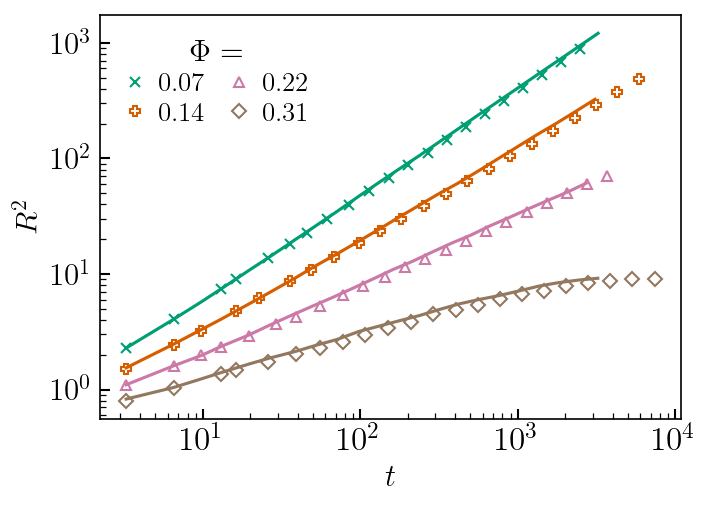

In [8]:

smldg = [
       "fluid", "sm1", "sm2", "sm3", "sm4",
       "sm5", "sm6", "sm7", "sm8", "sm9",
       "sm10", "sm11"]

smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]

se = np.asarray([5,8,10,11], dtype=int)
N = np.asarray([16384, 65536], dtype=int)
dl = 2*np.pi/np.sqrt(N[1])
A_s = dl*dl
fig, ax = plt.subplots()
tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset('fluid', "64KAll")
xx = 1e3*tMsd[0][2:]; yy = tMsd[1][2:] 
m, c = np.polyfit(np.log10(xx[xx>2e1]), np.log10(yy[xx>2e1]), 1)
Dl = 10**c
print(A_s/Dl)
upto=23
ip = 600
Deff, ph = [], []
for i, idx_p in enumerate(se):
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(smldg[idx_p], "64KAll")
    print(np.shape(tMsd))
    xx, yy = log_spaced(tMsd[1][1:],25)
    # xx = 1e3*tMsd[0][1:]*Dl/A_s; yy = tMsd[1][1:]/A_s 
    xx = 1e3*xx*Dl/A_s; yy = yy/A_s 
    # Deff.append(yy[ip]/xx[ip])
    phi = fractionSolid(Nsolid, N[1]) ## Pass the point corresponding to N=65536
    ph.append(phi) 
    l1, = ax.plot(xx[1:], yy[1:], smbl[idx_p], markerfacecolor='none',
                  markersize=5, markeredgewidth=1, color=clr[i+1], label=r"$%0.2f$"%(phi))

    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(smldg[idx_p], "64KAnAll")
    xx, yy = log_spaced(tMsd[1][1:],25)
    xx = 1e3*xx*Dl/A_s; yy = yy/A_s 

    l1, = ax.plot(xx[1:upto], yy[1:upto], "-", color=l1.get_color())

    # l1 = ax.plot(time*1e3, Msdlog/(4*np.pi**2), smbl[idx_p], markerfacecolor='none',
    #               markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(phi))

    #ax.plot(time[3:], (1.2*Diff)*time[3:]**alp, '--', color=clr[i], linewidth=1)

tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset("solid", "64K_solid")
xx, yy = log_spaced(tMsd[1][1:],50)
xx = 1e3*xx*Dl/A_s; yy = yy/A_s 

ax.set(xscale="log", yscale="log")
ax.legend(title=r'$\Phi=$ ', fontsize=13, ncols=2)
ax.set(xlabel=r"$t$", ylabel=r"$R^2$")
ax.set(xscale='log', yscale='log')
# ax.set(xlim=[1.8,2500])
# ax.axvspan(23, 400, alpha=0.3, color=clr[6])
# plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
# ax.text(-0.1, 1.0, "(A)", transform=ax.transAxes,**csfont, fontweight=450)
# plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
# fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/msdComp.pdf")
# x = np.asarray(Deff); y = np.asarray(ph)
# np.savetxt(dataFol+"/prev_results/deff_phi_free.txt", np.vstack([y, x]).T, fmt="%0.5e")
plt.show()




### First Passage time log-log

This source block is for the first passage time statistics.

/tmp/ipykernel_37777/2989320642.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set(xlim=[0,5700], ylim=[1e-3,2])


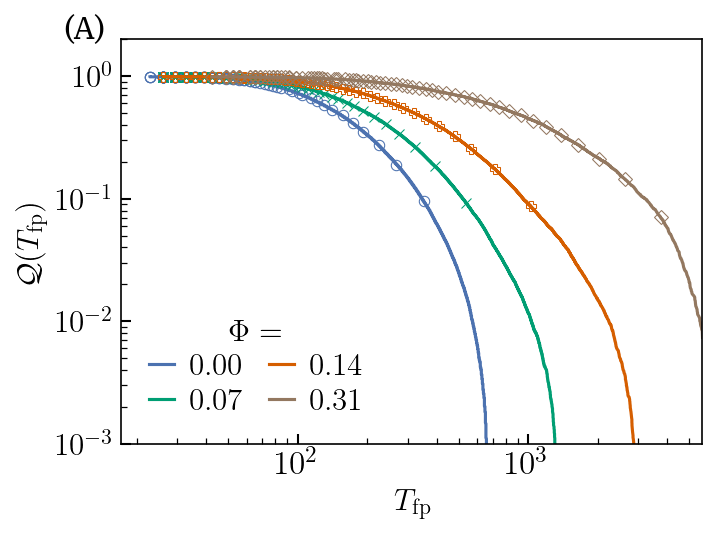

In [9]:

# for sm in smldg:

smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','x', 'D','x', 'X' ]
se = np.asarray([0,5,8,11], dtype=int)
N = np.asarray([16384, 65536], dtype=int)
cid = [0,1,2,4]
fig, ax = plt.subplots()
for i, idx_p in enumerate(se):
    tqpdf, rcut, Nsolid = firstPassageData(smldg[idx_p], "cut1")
    tmp, qpdf = log_spaced(tqpdf[1][:], 100); tmp, time = log_spaced(tqpdf[0][:], 100)
    # time, Msdstd = log_spaced(tMsd[2][1:], 50)
    phi = fractionSolid(Nsolid, N[1]) ## Pass the point corresponding to N=65536
    l1, = ax.plot(1e3*tqpdf[0]*Dl/A_s, 0.99 - tqpdf[1], "-" , color=clr[cid[i]], label=r"$%0.2f$"%(phi))
    ax.plot(1e3*time*Dl/A_s, 0.99 - qpdf, smbl[idx_p], color=l1.get_color(), markersize=5, markerfacecolor='none')
    # tmp, qpdf = log_spaced(tqpdf[1][-1000:], 30); tmp, time = log_spaced(tqpdf[0][-1000:], 30)
    # ax.plot(time, 0.99 - qpdf, smbl[idx_p], color=l1.get_color(), markersize=5, markerfacecolor='none')
thx = np.linspace(1,6.0e3,100)
thx1 = np.linspace(1,3e2,100)
# ax.plot(thx, 1.5 * np.exp(-8e-3 *thx), "--", linewidth=1, color="k")
# ax.plot(thx, 0.8 *np.exp(-7e-4 *thx), "--", linewidth=1, color="k")
ax.set(yscale="log", xscale="log")
ax.set(xlim=[0,5700], ylim=[1e-3,2]) 
ax.legend(title=r"$\Phi=$", ncols=2)
ax.set(xlabel=r"$T_{\rm {fp}}$", ylabel=r"$\mathcal{Q}(T_{\mathrm {fp}})$")
plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
ax.text(-0.1, 1.0, "(A)", transform=ax.transAxes,**csfont, fontweight=450)
plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
#fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/first_passage_time.pdf")
plt.show()




## Comparison of β with previous results

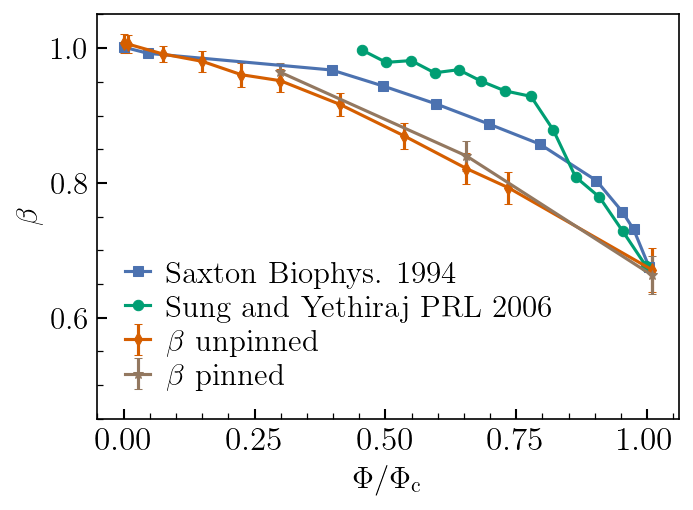

In [11]:

thisf = np.loadtxt(dataFol+"/prev_results/alp_phi.txt")
thisa = np.loadtxt(dataFol+"/prev_results/alp_phi_free.txt")
yeung = np.loadtxt(dataFol+"/prev_results/yethiraj_sung_prl96_2006.csv")
saxton = np.loadtxt(dataFol+"/prev_results/saxton_anomalous_biophys66_1994.csv")
fig, ax = plt.subplots()
ax.errorbar(thisf[:-1,0]/0.22,  thisf[:-1,1],
             yerr=thisf[:-1,2], fmt="-d", color="C2", capsize=2, markersize=5, label=r"$\beta$ unpinned")
ax.errorbar(thisa[:-1,0]/0.22,  thisa[:-1,1],
             yerr=thisa[:-1,2], fmt="-*", color="C4", capsize=2, markersize=5, label=r"$\beta$ pinned")
ax.plot(saxton[:,0]/0.5, (2.0/saxton[:,1]), "-s", markersize=5, label="Saxton Biophys. 1994")
ax.plot(yeung[:,0]/0.22, yeung[:,1], "-o", markersize=5, label="Sung and Yethiraj PRL 2006")
ax.set(xlabel=r"$\Phi/\Phi_{\rm c}$", ylabel=r"$\beta$")
ax.set(ylim=[0.45,1.05])
ax.legend(ncol=1)
# fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/BetaPhi.pdf")
plt.show()



## Deff pinned vs unpinned

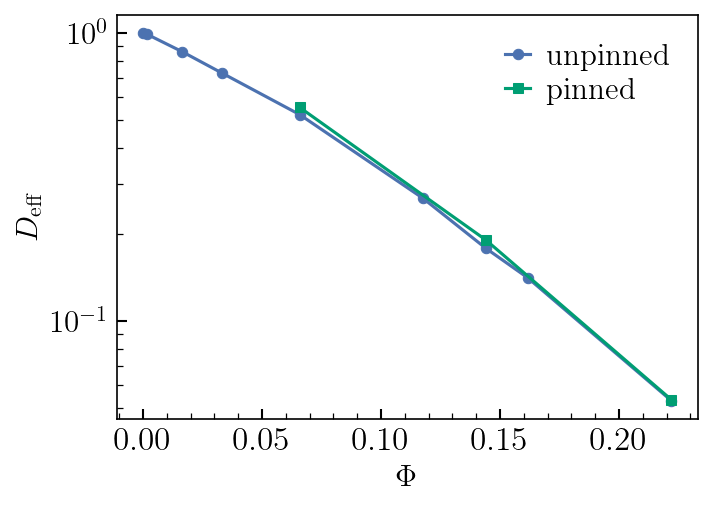

In [13]:

this = np.loadtxt(dataFol+"/prev_results/deff_phi.txt")
anch = np.loadtxt(dataFol+"/prev_results/deff_phi_a.txt")
fig, ax = plt.subplots()
ax.plot(this[:-2,0], this[:-2,1]/this[0,1], "-o", markersize=5, label=r"unpinned")
ax.plot(anch[:-1,0], anch[:-1,1]/this[0,1], "-s", markersize=5, label=r"pinned")
ax.set(xlabel=r"$\Phi$", ylabel=r"$D_{\rm eff}$", yscale="log")
ax.legend()
# plt.rcParams["text.usetex"]  = False #"IBM Plex Sans"
# ax.text(-0.1, 1.0, "(C)", transform=ax.transAxes,**csfont, fontweight=450)
# plt.rcParams["text.usetex"]  = True #"IBM Plex Sans"
#fig.savefig("/home/vikash/Documents/my_papers/semiSolidMembrane/fig/DeffPhi.pdf")
plt.show()



### Expansion plot

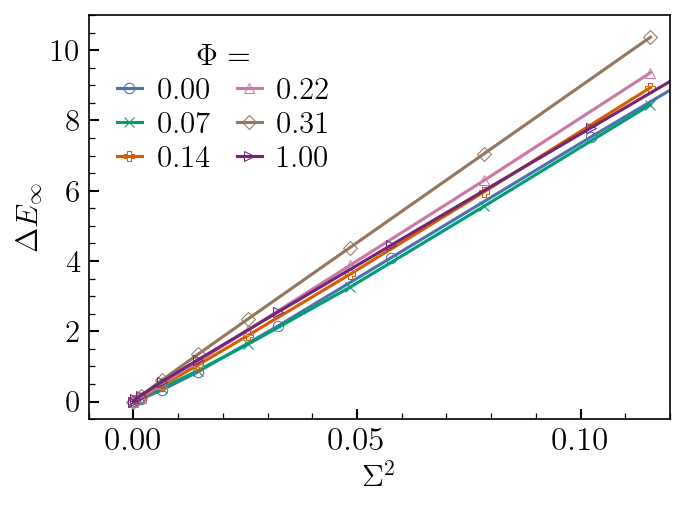

In [15]:
fol = ["exp/fluidexp.txt", "exp/smld5exp.txt", "exp/smld8exp.txt", "exp/smld10exp.txt", "exp/smld11exp.txt", "exp/solidexp.txt"]
se = np.asarray([0,5,8,10,11,12], dtype=int)
smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]
phis = [0.0,0.07, 0.14, 0.22, 0.31, 1.0] 

fig, ax = plt.subplots()  
for i,idx in enumerate(se):
    data = np.loadtxt(dataFol+fol[i])
    ax.plot(data[:,0], data[:,1],  marker=smbl[idx], markerfacecolor='none',
                 markersize=5,  label=r"$%0.2f$"%(phis[i]))

ax.legend(title=r"$\Phi=$", ncols=2)
ax.set(xlim=[-0.01,0.12], ylim=[-0.5,11.0])
ax.set(xlabel=r"$\Sigma^2$", ylabel=r"$\Delta E_\infty$")
plt.show()



## Comparison Deff phi previous results 

<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_37777/2222519117.py:12: SyntaxWarning: invalid escape sequence '\i'
  label="Javanainen {\it et al} Faraday Discuss (2013) \n (protein aggregrate)")
/tmp/ipykernel_37777/2222519117.py:15: SyntaxWarning: invalid escape sequence '\i'
  label="Javanainen {\it et al} Faraday Discuss (2013) \n (protein non aggregrate)")


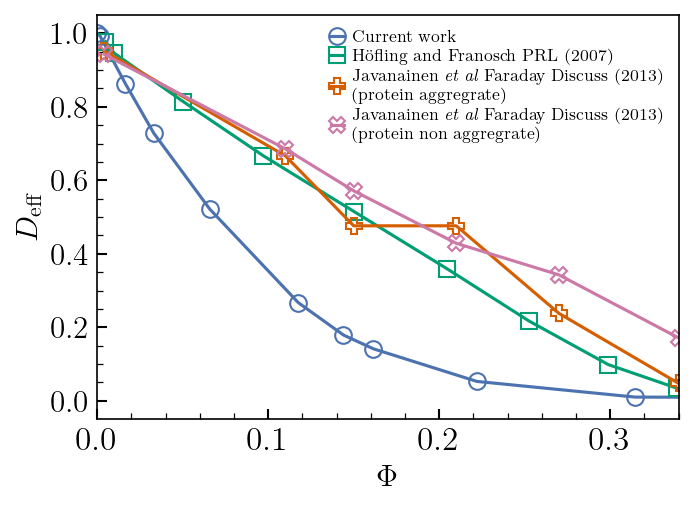

In [16]:

Deff_this = np.loadtxt(dataFol+"/prev_results/deff_phi.txt")
Deff_lorentz = np.loadtxt(dataFol+"/prev_results/hofling_correlations_lorentz.csv")
Deff_jan = np.loadtxt(dataFol+"/exp/DeffExpt.txt")

fig, ax = plt.subplots()
ax.plot(Deff_this[:,0], Deff_this[:,1]/Deff_this[0,1], '-o',
        markeredgewidth=1,markerfacecolor='none', markersize=8, label="Current work")
ax.plot(10**Deff_lorentz[:,0], Deff_lorentz[:,1], '-s',
        markeredgewidth=1,markerfacecolor='none', markersize=8, label=r"H\"ofling and Franosch PRL (2007)")
ax.plot(Deff_jan[:,1], Deff_jan[:,2]/2.1, '-P',
        markeredgewidth=1,markerfacecolor='none', markersize=8,
        label="Javanainen {\it et al} Faraday Discuss (2013) \n (protein aggregrate)")
ax.plot(Deff_jan[:,1], Deff_jan[:,3]/3.5, '-X',
        markeredgewidth=1,markerfacecolor='none', markersize=8,
        label="Javanainen {\it et al} Faraday Discuss (2013) \n (protein non aggregrate)")
ax.set(xlim=[0,0.34])
ax.set(xlabel=r"$\Phi$", ylabel=r"$D_{\rm eff}$")
ax.legend(fontsize=8.0)
fig.savefig("SimDeffComp.pdf")
plt.show()



## $\beta$ vs time


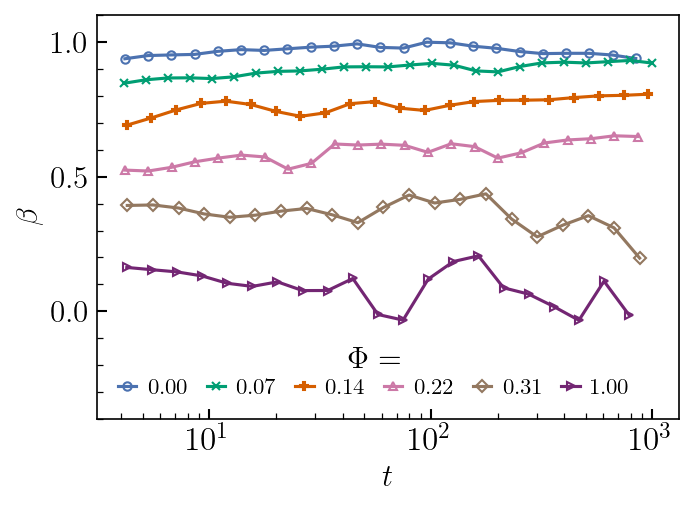

In [17]:
from scipy.interpolate import make_interp_spline, BSpline

# 300 represents number of points to make between T.min and T.max
def smoothMsd(T, msd):
    xnew = np.linspace(T.min(), T.max(), 30) 
    spl = make_interp_spline(T, msd, k=3)  # type: BSpline
    msds = spl(xnew)
    return xnew, msds

smldg = [
       "fluid", "sm1", "sm2", "sm3", "sm4",
       "sm5", "sm6", "sm7", "sm8", "sm9",
       "sm10", "sm11"]

smbl = ['o', 'x','x', 's','x','x','x','x', 'P', 'x','^', 'D','>', 'X' ]

se = np.asarray([0,5,8,10,11], dtype=int)
N = np.asarray([16384, 65536], dtype=int)
dl = 2*np.pi/np.sqrt(N[1])
A_s = dl*dl

def getBeta(X, Y):
    beta = []
    for i in range(1, len(X)-1):
        m, c = np.polyfit(np.asarray([X[i-1], X[i], X[i+1]]),
                          np.asarray([Y[i-1], Y[i], Y[i+1]]), 1)
        beta.append(m)
    return np.asarray(beta)  

def plotAlphaTime(fig, ax1):
    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset('fluid', "64KAll")
    xx = 1e3*tMsd[0][2:]; yy = tMsd[1][2:] 
    m, c = np.polyfit(np.log10(xx[xx>2e1]), np.log10(yy[xx>2e1]), 1)
    Dl = 10**c

    for i, idx_p in enumerate(se):
        tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset(smldg[idx_p], "64KAll")
        xx, yy = log_spaced(tMsd[1][1:],25)
        xx, yy = smoothMsd(np.log(xx[1:]), np.log(yy[1:]))
        beta = getBeta(xx[1:], yy[1:])
        Beta = np.diff(yy)/np.diff(xx)
        # xx, yy = smoothMsd((xx[1:]), (Beta[:]))
        xx = 1e3*np.exp(xx[1:-2])*Dl/A_s; yy = yy/A_s 
        phi = fractionSolid(Nsolid, N[1]) ## Pass the point corresponding to N=65536
        l1 = ax1.plot(xx[xx<1e3], beta[xx<1e3], "-"+smbl[idx_p], color=clr[i], markerfacecolor='none',
                      markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(phi))

    tMsd, alp, Diff, Nsolid, stdalp, stdDiff = readMsdDataset("solid", "64K_solid")
    xx, yy = log_spaced(tMsd[1][1:],25)
    xx, yy = smoothMsd(np.log(xx[1:]), np.log(yy[1:]))
    beta = getBeta(xx[1:], yy[1:])
    xx = 1e3*np.exp(xx[1:-2])*Dl/A_s; yy = yy/A_s 
    l1 = ax1.plot(xx[xx<1e3], beta[xx<1e3], "-"+smbl[idx_p+1], color=clr[i+1], markerfacecolor='none',
                  markersize=4, markeredgewidth=1, label=r"$%0.2f$"%(1.0))
    ax1.set(ylabel=r"$\beta$")
    # xx = np.linspace(10,2000,1000)
    # ax1.plot(xx, 1.2*xx, '--k', linewidth=2)
    # ax1.arrow(0.5, 0.8, 0.1, -0.5, transform=ax1.transAxes, length_includes_head=True,
    #            head_width=0.02, color="gray", visible=True, linewidth=2)
    x = 2;

fig1, ax1 = plt.subplots()

plotAlphaTime(fig1, ax1)

# ax1.grid(axis="x",linestyle = "dashed", color="k", fillstyle='full')
ax1.set(xscale='log', yscale='linear', ylim=[-0.4,1.1]) #, ylim=[-0.1, 1.1]
ax1.set(yticks=[0.0, 0.5, 1.0])
ax1.set_xlabel(r"$t$", **labelfont)
# ax1.axhline(1.0, ls="--", color="k")
ax1.legend(title=r'$\Phi=$ ', fontsize=11, ncols=6,
           frameon=True,fancybox=False, edgecolor="white", framealpha=1)
#fig1.savefig("/home/vikash/Documents/my_papers/semiSolidMembraneNew/fig/BetaTimenew.pdf")
plt.show()

